In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ultralytics/brain-tumor")

print("Path to dataset files:", path)

100%|██████████| 4.19M/4.19M [00:00<00:00, 6.12MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ultralytics/brain-tumor/versions/2


In [ ]:
# !pip install torch torchvision opencv-python tqdm matplotlib

import os
import glob
import random
import xml.etree.ElementTree as ET
import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import torchvision

import cv2
import numpy as np
from matplotlib import pyplot as plt

import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.9.0+cu126
CUDA available: True
Using device: cuda


In [ ]:
yaml_path = os.path.join(path, "brain-tumor.yaml")
with open(yaml_path, "r") as f:
    bt_cfg = yaml.safe_load(f)

DATA_ROOT = os.path.join(path, "brain-tumor")

IM_TRAIN_DIR = os.path.join(DATA_ROOT, "train", "images")
LABEL_TRAIN_DIR = os.path.join(DATA_ROOT, "train", "labels")
IM_VAL_DIR = os.path.join(DATA_ROOT, "valid", "images")
LABEL_VAL_DIR = os.path.join(DATA_ROOT, "valid", "labels")

MY_CLASSES = [bt_cfg["names"][k] for k in sorted(bt_cfg["names"].keys())]
NUM_CLASSES = 1 + len(MY_CLASSES)  # + 1 for background

# Hyper-parameters model
IM_CHANNELS = 3
ANCHOR_SCALES = [64, 128, 256]
ANCHOR_RATIOS = [0.5, 1.0, 2.0]
MIN_IM_SIZE = 600
MAX_IM_SIZE = 800
BACKBONE_OUT_CHANNELS = 512  # resnet18 layer4 output
FC_INNER_DIM = 1024

# RPN
RPN_BG_THRESH = 0.3
RPN_FG_THRESH = 0.7
RPN_NMS_THRESH = 0.7
RPN_TRAIN_PRENMS_TOPK = 12000
RPN_TEST_PRENMS_TOPK = 6000
RPN_TRAIN_TOPK = 2000
RPN_TEST_TOPK = 500
RPN_BATCH_SIZE = 256
RPN_POS_FRACTION = 0.5

# ROI
ROI_IOU_THRESH = 0.5
ROI_LOW_BG_IOU = 0.1
ROI_POOL_SIZE = 7
ROI_NMS_THRESH = 0.3
ROI_TOPK_DETECTIONS = 100
ROI_SCORE_THRESH = 0.5
ROI_BATCH_SIZE = 128
ROI_POS_FRACTION = 0.5

# Train
SEED = 1111
ACC_STEPS = 1
NUM_EPOCHS = 2
LR_STEPS = [12, 16]
LR = 1e-3

print("nClasses=", NUM_CLASSES)


nClasses= 3


In [ ]:
def preprocess_image(image_path, labels_dir):
    im = Image.open(image_path).convert('RGB')
    w, h = im.size

    stem = os.path.splitext(os.path.basename(image_path))[0]
    label_path = os.path.join(labels_dir, stem + ".txt")

    boxes = []
    labels = []
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                cx *= w
                cy *= h
                bw *= w
                bh *= h
                x1 = cx - bw / 2.0
                y1 = cy - bh / 2.0
                x2 = cx + bw / 2.0
                y2 = cy + bh / 2.0
                boxes.append([x1, y1, x2, y2])
                labels.append(cls_id + 1)

    if len(boxes) > 0:
        bboxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
    else:
        bboxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)

    im_tensor = torch.from_numpy(np.array(im)).permute(2, 0, 1).float() / 255.0

    return im_tensor, bboxes, labels


class BrainTumorYoloDataset(Dataset):
    def __init__(self, images_dir, labels_dir, classes, split="train"):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.split = split

        classes = ['background'] + list(classes)
        self.label2idx = {cls_name: i for i, cls_name in enumerate(classes)}
        self.idx2label = {i: cls_name for i, cls_name in enumerate(classes)}

        all_image_paths = sorted(glob.glob(os.path.join(self.images_dir, "*.jpg")))
        print(f"[{split}] Found {len(all_image_paths)} images in {self.images_dir}")

        self.image_paths = []
        for img_path in all_image_paths:
            stem = os.path.splitext(os.path.basename(img_path))[0]
            label_path = os.path.join(self.labels_dir, stem + ".txt")

            if os.path.exists(label_path):
                with open(label_path, "r") as f:
                    lines = [line.strip() for line in f.readlines() if line.strip()]
                    valid_lines = [line for line in lines if len(line.split()) == 5]
                    if len(valid_lines) > 0:
                        self.image_paths.append(img_path)

        print(f"[{split}] After filtering: {len(self.image_paths)} images with labels")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        im_tensor, bboxes, labels = preprocess_image(img_path, self.labels_dir)

        targets = {
            'bboxes': bboxes,
            'labels': labels,
        }
        return im_tensor, targets, img_path

    def __str__(self):
        """Return dataset information as string."""
        num_boxes_list = []
        label_counts = {}

        sample_size = len(self.image_paths)  # ALL images

        for i in range(sample_size):
            img, target, fname = self[i]
            num_boxes = target['bboxes'].shape[0]
            num_boxes_list.append(num_boxes)

            for label in target['labels'].cpu().numpy():
                label_name = self.idx2label[int(label)]
                label_counts[label_name] = label_counts.get(label_name, 0) + 1

        info = f"BrainTumorYoloDataset ({self.split})\n"
        info += "=" * 60 + "\n"
        info += f"Split: {self.split}\n"
        info += f"Number of images: {len(self.image_paths)}\n"
        info += f"Images directory: {self.images_dir}\n"
        info += f"Labels directory: {self.labels_dir}\n"
        info += f"Classes: {list(self.label2idx.keys())}\n"
        info += f"Number of classes (including background): {len(self.label2idx)}\n"
        info += f"Label mapping: {self.idx2label}\n"

        if num_boxes_list:
            info += f"\nStatistics (from ALL images):\n"
            info += f"  - Num boxes: {sum(num_boxes_list):.2f}\n"
            info += f"  - Min boxes: {min(num_boxes_list)}\n"
            info += f"  - Max boxes: {max(num_boxes_list)}\n"
            info += f"  - Label distribution: {label_counts}\n"

        info += "=" * 60
        return info


from torch.utils.data import random_split

full_train_dataset = BrainTumorYoloDataset(IM_TRAIN_DIR, LABEL_TRAIN_DIR, MY_CLASSES, split='train')

# Split train into train and validation (80% train, 20% val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

test_dataset = BrainTumorYoloDataset(IM_VAL_DIR, LABEL_VAL_DIR, MY_CLASSES, split='test')

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)


[train] Found 893 images in /root/.cache/kagglehub/datasets/ultralytics/brain-tumor/versions/2/brain-tumor/train/images
[train] After filtering: 878 images with labels
[test] Found 223 images in /root/.cache/kagglehub/datasets/ultralytics/brain-tumor/versions/2/brain-tumor/valid/images
[test] After filtering: 223 images with labels


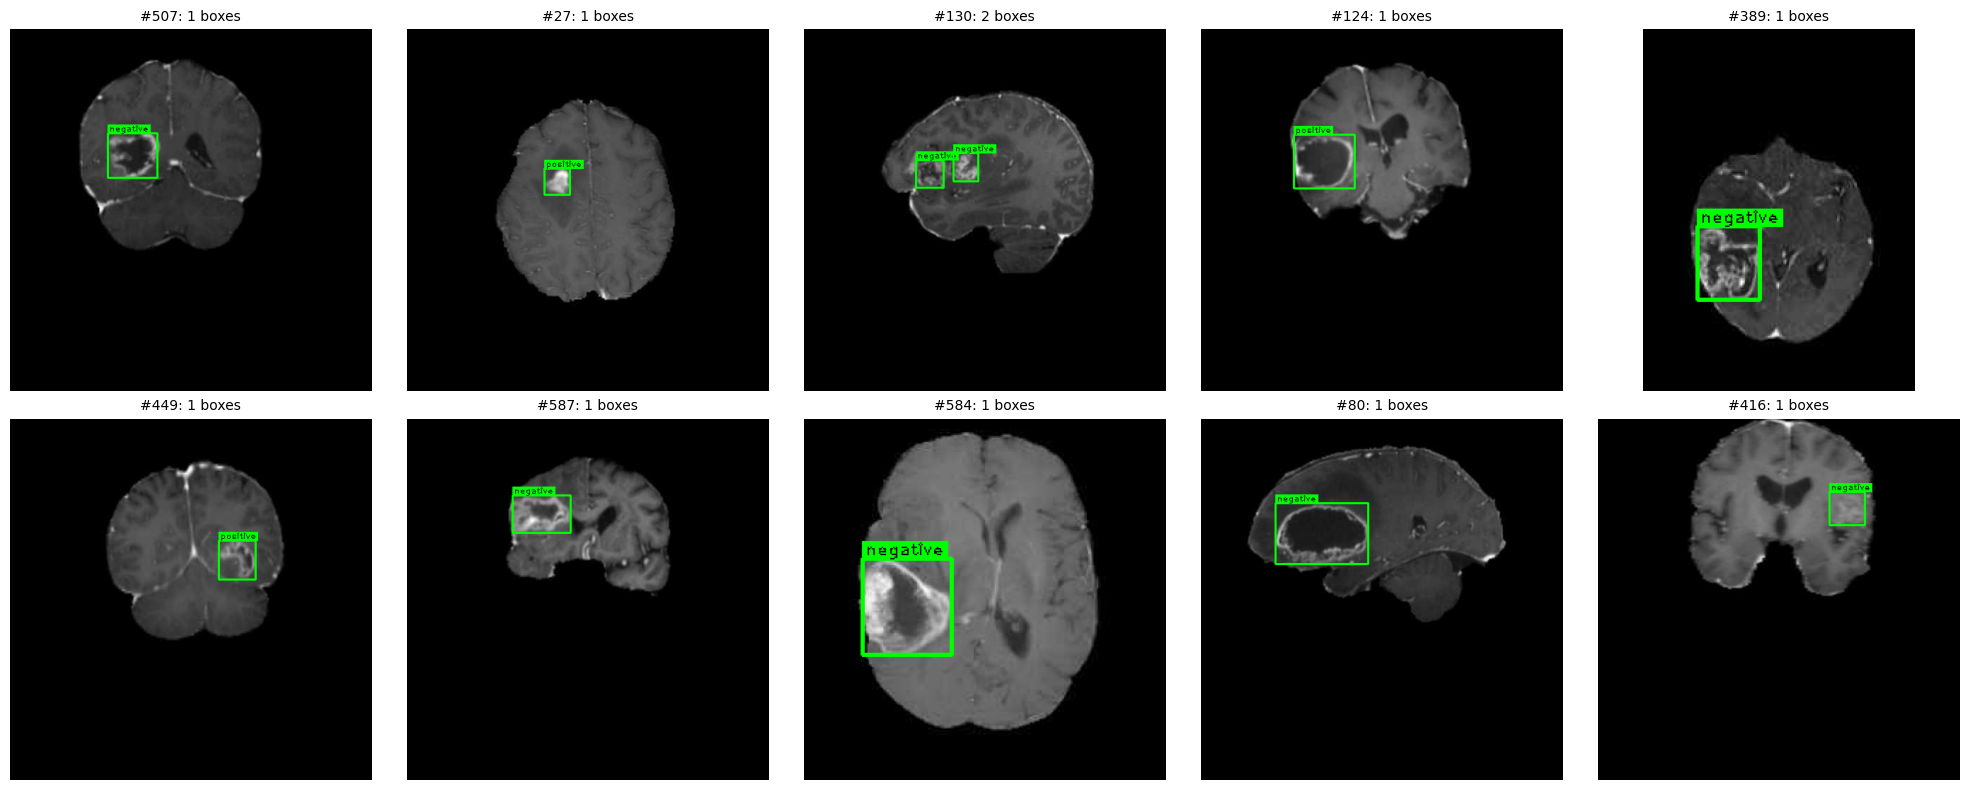

In [ ]:
num_samples = min(10, len(train_dataset))
random_indices = random.sample(range(len(train_dataset)), num_samples)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, ax in zip(random_indices, axes):
    img, target, fname = train_dataset[idx]

    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    vis = img_bgr.copy()

    gt_boxes = target['bboxes'].cpu().numpy()
    gt_labels = target['labels'].cpu().numpy()

    for box, label in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label_name = train_dataset.dataset.idx2label[int(label)]
        text = f"{label_name}"
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_PLAIN, 0.8, 1)
        cv2.rectangle(vis, (x1, y1 - th - 4), (x1 + tw + 4, y1), (0, 255, 0), -1)
        cv2.putText(vis, text, (x1 + 2, y1 - 2), cv2.FONT_HERSHEY_PLAIN, 0.8, (0, 0, 0), 1)

    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    ax.imshow(vis_rgb)
    ax.axis('off')
    ax.set_title(f"#{idx}: {len(gt_boxes)} boxes", fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Define utility functions + backbone + RPN + ROI Head + FasterRCNN (self-implemented)

def get_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    x_left = torch.max(boxes1[:, None, 0], boxes2[:, 0])
    y_top = torch.max(boxes1[:, None, 1], boxes2[:, 1])
    x_right = torch.min(boxes1[:, None, 2], boxes2[:, 2])
    y_bottom = torch.min(boxes1[:, None, 3], boxes2[:, 3])

    inter = (x_right - x_left).clamp(min=0) * (y_bottom - y_top).clamp(min=0)
    union = area1[:, None] + area2 - inter
    return inter / (union + 1e-6)


def boxes_to_targets(gt_boxes, anchors_or_proposals):
    widths = anchors_or_proposals[:, 2] - anchors_or_proposals[:, 0]
    heights = anchors_or_proposals[:, 3] - anchors_or_proposals[:, 1]
    ctr_x = anchors_or_proposals[:, 0] + 0.5 * widths
    ctr_y = anchors_or_proposals[:, 1] + 0.5 * heights

    gt_widths = gt_boxes[:, 2] - gt_boxes[:, 0]
    gt_heights = gt_boxes[:, 3] - gt_boxes[:, 1]
    gt_ctr_x = gt_boxes[:, 0] + 0.5 * gt_widths
    gt_ctr_y = gt_boxes[:, 1] + 0.5 * gt_heights

    dx = (gt_ctr_x - ctr_x) / widths
    dy = (gt_ctr_y - ctr_y) / heights
    dw = torch.log(gt_widths / widths)
    dh = torch.log(gt_heights / heights)
    return torch.stack([dx, dy, dw, dh], dim=1)


def apply_deltas(deltas, anchors_or_proposals):
    w = anchors_or_proposals[:, 2] - anchors_or_proposals[:, 0]
    h = anchors_or_proposals[:, 3] - anchors_or_proposals[:, 1]
    ctr_x = anchors_or_proposals[:, 0] + 0.5 * w
    ctr_y = anchors_or_proposals[:, 1] + 0.5 * h

    dx = deltas[:, 0]
    dy = deltas[:, 1]
    dw = deltas[:, 2].clamp(max=np.log(1000.0 / 16))
    dh = deltas[:, 3].clamp(max=np.log(1000.0 / 16))

    pred_ctr_x = dx * w + ctr_x
    pred_ctr_y = dy * h + ctr_y
    pred_w = torch.exp(dw) * w
    pred_h = torch.exp(dh) * h

    x1 = pred_ctr_x - 0.5 * pred_w
    y1 = pred_ctr_y - 0.5 * pred_h
    x2 = pred_ctr_x + 0.5 * pred_w
    y2 = pred_ctr_y + 0.5 * pred_h
    return torch.stack([x1, y1, x2, y2], dim=1)


def clamp_boxes(boxes, image_shape):
    h, w = image_shape
    boxes[:, 0::2] = boxes[:, 0::2].clamp(0, w)
    boxes[:, 1::2] = boxes[:, 1::2].clamp(0, h)
    return boxes


# Sampling pos/neg

def sample_pos_neg(labels, pos_count, total_count):
    pos_idx = torch.where(labels >= 1)[0]
    neg_idx = torch.where(labels == 0)[0]
    num_pos = min(pos_idx.numel(), pos_count)
    num_neg = min(neg_idx.numel(), total_count - num_pos)

    perm_pos = torch.randperm(pos_idx.numel(), device=labels.device)[:num_pos]
    perm_neg = torch.randperm(neg_idx.numel(), device=labels.device)[:num_neg]

    pos_idx = pos_idx[perm_pos]
    neg_idx = neg_idx[perm_neg]
    mask_pos = torch.zeros_like(labels, dtype=torch.bool)
    mask_neg = torch.zeros_like(labels, dtype=torch.bool)
    mask_pos[pos_idx] = True
    mask_neg[neg_idx] = True
    return mask_neg, mask_pos


# Backbone using ResNet18 pretrained from torchvision

class ResNetBackbone(nn.Module):
    def __init__(self, out_channels=BACKBONE_OUT_CHANNELS, freeze_until_layer=3):
        """
        freeze_until_layer: number of initial blocks to freeze (0-4), 3 means freeze conv1+layer1+layer2.
        """
        super().__init__()
        resnet = torchvision.models.resnet18(pretrained=True)
        # Remove avgpool and fc, keep up to layer4: output C=512, stride=32
        self.body = nn.Sequential(*list(resnet.children())[:-2])

        # Optionally freeze part of backbone for more stability with small datasets
        child_layers = list(self.body.children())
        for i, layer in enumerate(child_layers):
            if i <= freeze_until_layer:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, x):
        return self.body(x)


# RPN

class RegionProposalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.scales = ANCHOR_SCALES
        self.ratios = ANCHOR_RATIOS
        self.low_iou = RPN_BG_THRESH
        self.high_iou = RPN_FG_THRESH
        self.nms_thresh = RPN_NMS_THRESH
        self.batch_size = RPN_BATCH_SIZE
        self.pos_fraction = RPN_POS_FRACTION

        self.conv = nn.Conv2d(BACKBONE_OUT_CHANNELS, BACKBONE_OUT_CHANNELS, 3, padding=1)
        self.num_anchors = len(self.scales) * len(self.ratios)
        self.cls_logits = nn.Conv2d(BACKBONE_OUT_CHANNELS, self.num_anchors, 1)
        self.bbox_pred = nn.Conv2d(BACKBONE_OUT_CHANNELS, self.num_anchors * 4, 1)

        for l in [self.conv, self.cls_logits, self.bbox_pred]:
            nn.init.normal_(l.weight, std=0.01)
            nn.init.constant_(l.bias, 0)

    def _generate_anchors(self, image, feat):
        N, C, H, W = feat.shape
        _, _, H_img, W_img = image.shape

        stride_h = H_img // H
        stride_w = W_img // W

        scales = torch.as_tensor(self.scales, dtype=feat.dtype, device=feat.device)
        ratios = torch.as_tensor(self.ratios, dtype=feat.dtype, device=feat.device)

        h_ratios = torch.sqrt(ratios)
        w_ratios = 1.0 / h_ratios
        ws = (w_ratios[:, None] * scales[None, :]).reshape(-1)
        hs = (h_ratios[:, None] * scales[None, :]).reshape(-1)
        base_anchors = torch.stack([-ws, -hs, ws, hs], dim=1) / 2.0

        shifts_x = torch.arange(0, W, device=feat.device) * stride_w
        shifts_y = torch.arange(0, H, device=feat.device) * stride_h
        shifts_y, shifts_x = torch.meshgrid(shifts_y, shifts_x, indexing="ij")
        shifts = torch.stack([shifts_x.reshape(-1), shifts_y.reshape(-1),
                              shifts_x.reshape(-1), shifts_y.reshape(-1)], dim=1)
        anchors = (shifts[:, None, :] + base_anchors[None, :, :]).reshape(-1, 4)
        return anchors

    def _assign_targets(self, anchors, gt_boxes):
        ious = get_iou(gt_boxes, anchors)  # (G, A)
        max_iou, gt_idx = ious.max(dim=0)

        labels = torch.full((anchors.size(0),), -1, dtype=torch.float32, device=anchors.device)
        labels[max_iou < self.low_iou] = 0
        labels[max_iou >= self.high_iou] = 1

        matched_gt = gt_boxes[gt_idx.clamp(min=0)]
        return labels, matched_gt

    def forward(self, image, feat, target=None):
        t = F.relu(self.conv(feat))
        logits = self.cls_logits(t)
        bbox_deltas = self.bbox_pred(t)

        A = self.num_anchors
        N, _, H, W = logits.shape

        logits = logits.permute(0, 2, 3, 1).reshape(-1, 1)
        bbox_deltas = bbox_deltas.view(N, A, 4, H, W).permute(0, 3, 4, 1, 2).reshape(-1, 4)

        anchors = self._generate_anchors(image, feat)
        proposals = apply_deltas(bbox_deltas.detach(), anchors)

        scores = torch.sigmoid(logits.reshape(-1))
        num_pre = RPN_TRAIN_PRENMS_TOPK if self.training else RPN_TEST_PRENMS_TOPK
        num_pre = min(num_pre, scores.numel())
        topk_scores, topk_idx = scores.topk(num_pre)
        proposals = proposals[topk_idx]

        H_img, W_img = image.shape[-2:]
        proposals = clamp_boxes(proposals, (H_img, W_img))

        ws = proposals[:, 2] - proposals[:, 0]
        hs = proposals[:, 3] - proposals[:, 1]
        keep = (ws >= 16) & (hs >= 16)
        # keep = (ws >= 8) & (hs >= 8)
        proposals = proposals[keep]
        topk_scores = topk_scores[keep]

        keep_idx = torchvision.ops.nms(proposals, topk_scores, self.nms_thresh)
        num_post = RPN_TRAIN_TOPK if self.training else RPN_TEST_TOPK
        keep_idx = keep_idx[:num_post]

        proposals = proposals[keep_idx]
        topk_scores = topk_scores[keep_idx]

        out = {
            'proposals': proposals,
            'scores': topk_scores,
        }

        if (not self.training) or (target is None):
            return out

        labels, matched_gt = self._assign_targets(anchors, target['bboxes'][0])
        reg_targets = boxes_to_targets(matched_gt, anchors)

        pos_count = int(self.pos_fraction * self.batch_size)
        neg_mask, pos_mask = sample_pos_neg(labels, pos_count, self.batch_size)
        sample_idx = torch.where(neg_mask | pos_mask)[0]

        loc_loss = F.smooth_l1_loss(
            bbox_deltas[pos_mask], reg_targets[pos_mask], beta=1/9, reduction='sum'
        ) / sample_idx.numel()
        cls_loss = F.binary_cross_entropy_with_logits(
            logits[sample_idx].flatten(), labels[sample_idx].flatten()
        )

        out['rpn_classification_loss'] = cls_loss
        out['rpn_localization_loss'] = loc_loss
        return out


In [ ]:
# ROI Head & FasterRCNN (tiếp tục)

class ROIHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.num_classes = NUM_CLASSES
        self.roi_batch_size = ROI_BATCH_SIZE
        self.roi_pos_fraction = ROI_POS_FRACTION
        self.iou_thresh = ROI_IOU_THRESH
        self.low_bg_iou = ROI_LOW_BG_IOU
        self.nms_thresh = ROI_NMS_THRESH
        self.topk = ROI_TOPK_DETECTIONS
        self.score_thresh = ROI_SCORE_THRESH
        self.pool_size = ROI_POOL_SIZE
        self.fc_dim = FC_INNER_DIM

        self.fc6 = nn.Linear(BACKBONE_OUT_CHANNELS * self.pool_size * self.pool_size, self.fc_dim)
        self.fc7 = nn.Linear(self.fc_dim, self.fc_dim)
        self.cls_layer = nn.Linear(self.fc_dim, self.num_classes)
        self.bbox_layer = nn.Linear(self.fc_dim, self.num_classes * 4)

    def _assign_targets_to_proposals(self, proposals, gt_boxes, gt_labels):
        ious = get_iou(gt_boxes, proposals)
        max_iou, gt_idx = ious.max(dim=0)

        bg = (max_iou < self.iou_thresh) & (max_iou >= self.low_bg_iou)
        ignore = max_iou < self.low_bg_iou

        matched_gt_boxes = gt_boxes[gt_idx.clamp(min=0)]
        labels = gt_labels[gt_idx.clamp(min=0)].clone()
        labels[bg] = 0
        labels[ignore] = -1
        return labels, matched_gt_boxes

    def _roi_pool(self, feat, proposals, image_shape):
        # simple self-implemented ROI Pool using adaptive max pool after crop
        pooled = []
        _, C, H, W = feat.shape
        H_img, W_img = image_shape
        scale_y = H / float(H_img)
        scale_x = W / float(W_img)

        for box in proposals:
            x1, y1, x2, y2 = box
            x1 = int(x1 * scale_x)
            x2 = int(x2 * scale_x)
            y1 = int(y1 * scale_y)
            y2 = int(y2 * scale_y)
            x1 = max(0, min(x1, W - 1))
            x2 = max(0, min(x2, W - 1))
            y1 = max(0, min(y1, H - 1))
            y2 = max(0, min(y2, H - 1))
            if x2 <= x1 or y2 <= y1:
                crop = feat[:, :, :1, :1]
            else:
                crop = feat[:, :, y1:y2, x1:x2]
            pooled_feat = F.adaptive_max_pool2d(crop, (self.pool_size, self.pool_size))
            pooled.append(pooled_feat)
        pooled = torch.cat(pooled, dim=0)
        return pooled

    def forward(self, feat, proposals, image_shape, target=None):
        if self.training and target is not None:
            gt_boxes = target['bboxes'][0]
            gt_labels = target['labels'][0]

            proposals = torch.cat([proposals, gt_boxes], dim=0)
            labels, matched_gt = self._assign_targets_to_proposals(proposals, gt_boxes, gt_labels)

            pos_count = int(self.roi_pos_fraction * self.roi_batch_size)
            neg_mask, pos_mask = sample_pos_neg(labels, pos_count, self.roi_batch_size)
            sample_idx = torch.where(neg_mask | pos_mask)[0]

            proposals = proposals[sample_idx]
            labels = labels[sample_idx]
            matched_gt = matched_gt[sample_idx]
            reg_targets = boxes_to_targets(matched_gt, proposals)
        else:
            labels = None
            reg_targets = None

        from torchvision.ops import roi_align
        device = feat.device
        _, _, H, W = feat.shape
        H_img, W_img = image_shape

        scale_x = W / W_img
        scale_y = H / H_img

        boxes = proposals.clone()
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y

        roi_boxes = torch.cat(
            [torch.zeros((boxes.size(0), 1), device=device), boxes],
            dim=1
        )

        pooled = roi_align(
            feat,
            roi_boxes,
            output_size=(self.pool_size, self.pool_size),
            spatial_scale=1.0,
            sampling_ratio=2,
            aligned=True
        )

        pooled = pooled.view(pooled.size(0), -1)
        fc6 = F.relu(self.fc6(pooled))
        fc7 = F.relu(self.fc7(fc6))
        cls_scores = self.cls_layer(fc7)
        bbox_pred = self.bbox_layer(fc7).view(-1, self.num_classes, 4)

        out = {}
        if self.training and target is not None:
            cls_loss = F.cross_entropy(cls_scores, labels)

            fg_idx = torch.where(labels > 0)[0]
            if fg_idx.numel() > 0:
                cls_fg = labels[fg_idx]
                loc_loss = F.smooth_l1_loss(
                    bbox_pred[fg_idx, cls_fg], reg_targets[fg_idx], beta=1/9, reduction='sum'
                ) / labels.numel()
            else:
                loc_loss = torch.tensor(0.0, device=feat.device)

            out['frcnn_classification_loss'] = cls_loss
            out['frcnn_localization_loss'] = loc_loss
            return out

        # Inference
        probs = F.softmax(cls_scores, dim=-1)
        boxes_all = []
        scores_all = []
        labels_all = []

        for c in range(1, self.num_classes):
            cls_prob = probs[:, c]
            keep = cls_prob > self.score_thresh
            if keep.sum() == 0:
                continue
            cls_prob = cls_prob[keep]
            cls_boxes = apply_deltas(bbox_pred[keep, c], proposals[keep])
            cls_boxes = clamp_boxes(cls_boxes, image_shape)

            keep_idx = torchvision.ops.nms(cls_boxes, cls_prob, self.nms_thresh)
            keep_idx = keep_idx[:self.topk]

            boxes_all.append(cls_boxes[keep_idx])
            scores_all.append(cls_prob[keep_idx])
            labels_all.append(torch.full((keep_idx.numel(),), c, dtype=torch.int64, device=feat.device))

        if len(boxes_all) == 0:
            out['boxes'] = torch.zeros((0, 4), device=feat.device)
            out['scores'] = torch.zeros((0,), device=feat.device)
            out['labels'] = torch.zeros((0,), dtype=torch.int64, device=feat.device)
        else:
            out['boxes'] = torch.cat(boxes_all, dim=0)
            out['scores'] = torch.cat(scores_all, dim=0)
            out['labels'] = torch.cat(labels_all, dim=0)
        return out


class FasterRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = ResNetBackbone()
        self.rpn = RegionProposalNetwork()
        self.roi_head = ROIHead()

        self.image_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.image_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def _preprocess(self, image, bboxes=None):
        image = (image - self.image_mean.to(image.device)) / self.image_std.to(image.device)
        h, w = image.shape[-2:]
        min_size = min(h, w)
        max_size = max(h, w)
        scale = min(MIN_IM_SIZE / min_size, MAX_IM_SIZE / max_size)
        new_h = int(h * scale)
        new_w = int(w * scale)
        image = F.interpolate(image[None], size=(new_h, new_w), mode='bilinear', align_corners=False)[0]
        if bboxes is not None:
            bboxes = bboxes * torch.tensor([new_w / w, new_h / h, new_w / w, new_h / h], device=bboxes.device)
        return image, bboxes, (h, w)

    def forward(self, image, target=None):
        # image: (1, 3, H, W)
        old_shape = image.shape[-2:]
        if self.training and target is not None:
            image_proc, bboxes, _ = self._preprocess(image[0], target['bboxes'][0])
            target['bboxes'] = bboxes.unsqueeze(0)
        else:
            image_proc, _, _ = self._preprocess(image[0], None)
        image_proc = image_proc.unsqueeze(0)

        feat = self.backbone(image_proc)
        rpn_out = self.rpn(image_proc, feat, target)
        proposals = rpn_out['proposals']

        roi_out = self.roi_head(feat, proposals, image_proc.shape[-2:], target)

        if not self.training:
            # scale boxes back to original size
            new_h, new_w = image_proc.shape[-2:]
            ratio_h = old_shape[0] / new_h
            ratio_w = old_shape[1] / new_w
            boxes = roi_out['boxes']
            boxes = boxes * torch.tensor([ratio_w, ratio_h, ratio_w, ratio_h], device=boxes.device)
            roi_out['boxes'] = boxes

        return rpn_out, roi_out


# Initialize model, optimizer, scheduler
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = FasterRCNN().to(device)
model.train()

optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4,
)

from torch.optim.lr_scheduler import MultiStepLR
scheduler = MultiStepLR(optimizer, milestones=LR_STEPS, gamma=0.1)

print("Model Faster R-CNN initialized.")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


Model Faster R-CNN initialized.


In [ ]:
history = {
    "epoch": [],

    "train/rpn_cls_loss": [],
    "train/rpn_loc_loss": [],
    "train/frcnn_cls_loss": [],
    "train/frcnn_loc_loss": [],
    "train/total_loss": [],

    "metrics/precision": [],
    "metrics/recall": [],
    "metrics/mAP50": [],
    "metrics/mean_iou": []
}

def calc_image_metrics(gt_boxes, pred_boxes, iou_thr=0.5):
    N_gt, N_pred = len(gt_boxes), len(pred_boxes)

    if N_gt == 0 and N_pred == 0:
        return 0, 0, 0, [], np.zeros(N_pred, dtype=bool)
    if N_gt == 0:
        return 0, N_pred, 0, [], np.zeros(N_pred, dtype=bool)
    if N_pred == 0:
        return 0, 0, N_gt, [], np.zeros(N_pred, dtype=bool)

    iou_matrix = get_iou(
        torch.tensor(gt_boxes, dtype=torch.float32),
        torch.tensor(pred_boxes, dtype=torch.float32)
    ).cpu().numpy()

    gt_matched = np.zeros(N_gt, dtype=bool)
    pred_matched = np.zeros(N_pred, dtype=bool)
    ious = []

    while True:
        gt_idx, pred_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
        max_iou = iou_matrix[gt_idx, pred_idx]
        if max_iou < iou_thr:
            break

        if not gt_matched[gt_idx] and not pred_matched[pred_idx]:
            gt_matched[gt_idx] = True
            pred_matched[pred_idx] = True
            ious.append(max_iou)
            iou_matrix[gt_idx, :] = -1
            iou_matrix[:, pred_idx] = -1
        else:
            iou_matrix[gt_idx, pred_idx] = -1

    TP = pred_matched.sum()
    FP = (~pred_matched).sum()
    FN = (~gt_matched).sum()

    return TP, FP, FN, ious, pred_matched

def evaluate_model(model, data_loader, device, iou_thr=0.5):
    model.eval()

    total_TP = total_FP = total_FN = 0
    all_preds = []
    all_ious = []

    with torch.no_grad():
        for im, target, fname in tqdm(data_loader, desc="Evaluating"):
            im = im.to(device)
            gt_boxes = target['bboxes'].squeeze(0).cpu().numpy()

            _, out = model(im, None)
            boxes = out['boxes'].cpu().numpy()
            scores = out['scores'].cpu().numpy()

            idxs = np.argsort(-scores)
            boxes, scores = boxes[idxs], scores[idxs]

            TP, FP, FN, ious, pred_matched = calc_image_metrics(gt_boxes, boxes, iou_thr)

            total_TP += TP
            total_FP += FP
            total_FN += FN
            all_ious.extend(ious)

            for s, m in zip(scores, pred_matched):
                all_preds.append((s, int(m)))

    return total_TP, total_FP, total_FN, all_ious, all_preds


model.train()

NUM_EPOCHS = 10


for epoch in range(NUM_EPOCHS):
    model.train()

    rpn_cls_losses, rpn_loc_losses = [], []
    frcnn_cls_losses, frcnn_loc_losses = [], []

    optimizer.zero_grad()

    for im, target, fname in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        im = im.to(device)
        target['bboxes'] = target['bboxes'].to(device)
        target['labels'] = target['labels'].to(device)

        rpn_out, frcnn_out = model(im, target)

        rpn_loss = rpn_out['rpn_classification_loss'] + rpn_out['rpn_localization_loss']
        frcnn_loss = frcnn_out['frcnn_classification_loss'] + frcnn_out['frcnn_localization_loss']
        loss = rpn_loss + frcnn_loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        rpn_cls_losses.append(rpn_out['rpn_classification_loss'].item())
        rpn_loc_losses.append(rpn_out['rpn_localization_loss'].item())
        frcnn_cls_losses.append(frcnn_out['frcnn_classification_loss'].item())
        frcnn_loc_losses.append(frcnn_out['frcnn_localization_loss'].item())

    scheduler.step()

    TP, FP, FN, list_ious, all_preds = evaluate_model(
        model, val_loader, device, iou_thr=0.5
    )

    if len(all_preds) == 0:
        map50 = 0.0
    else:
        scores, matches = zip(*all_preds)
        prec_curve, rec_curve, _ = precision_recall_curve(matches, scores)
        map50 = auc(rec_curve, prec_curve)

    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    mean_iou = np.mean(list_ious) if list_ious else 0

    train_rpn_cls = np.mean(rpn_cls_losses)
    train_rpn_loc = np.mean(rpn_loc_losses)
    train_frcnn_cls = np.mean(frcnn_cls_losses)
    train_frcnn_loc = np.mean(frcnn_loc_losses)
    train_total = train_rpn_cls + train_rpn_loc + train_frcnn_cls + train_frcnn_loc

    history["epoch"].append(epoch + 1)

    history["train/rpn_cls_loss"].append(train_rpn_cls)
    history["train/rpn_loc_loss"].append(train_rpn_loc)
    history["train/frcnn_cls_loss"].append(train_frcnn_cls)
    history["train/frcnn_loc_loss"].append(train_frcnn_loc)
    history["train/total_loss"].append(train_total)

    history["metrics/precision"].append(precision)
    history["metrics/recall"].append(recall)
    history["metrics/mAP50"].append(map50)
    history["metrics/mean_iou"].append(mean_iou)


Epoch 1 - Training:   0%|          | 0/702 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 2 - Training:   0%|          | 0/702 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 3 - Training:   0%|          | 0/702 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 9 - Training:   0%|          | 0/702 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 10 - Training:   0%|          | 0/702 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/176 [00:00<?, ?it/s]

In [ ]:
results = pd.DataFrame(history)
results.to_csv("training_results.csv", index=False)
results.head()

,epoch,train/rpn_cls_loss,train/rpn_loc_loss,train/frcnn_cls_loss,train/frcnn_loc_loss,train/total_loss,metrics/precision,metrics/recall,metrics/mAP50,metrics/mean_iou
0,1,0.027048,0.000220,0.162783,0.012504,0.202556,0.000000,0.000000,0.000000,0.000000
1,2,0.003386,0.000163,0.119366,0.009788,0.132703,0.000000,0.000000,0.000000,0.000000
2,3,0.002609,0.000135,0.102288,0.009025,0.114057,0.960000,0.126984,0.972738,0.701160
3,4,0.002176,0.000130,0.091651,0.008238,0.102194,0.947368,0.380952,0.950479,0.725236
4,5,0.001907,0.000112,0.082805,0.007764,0.092587,0.875000,0.370370,0.906413,0.728090


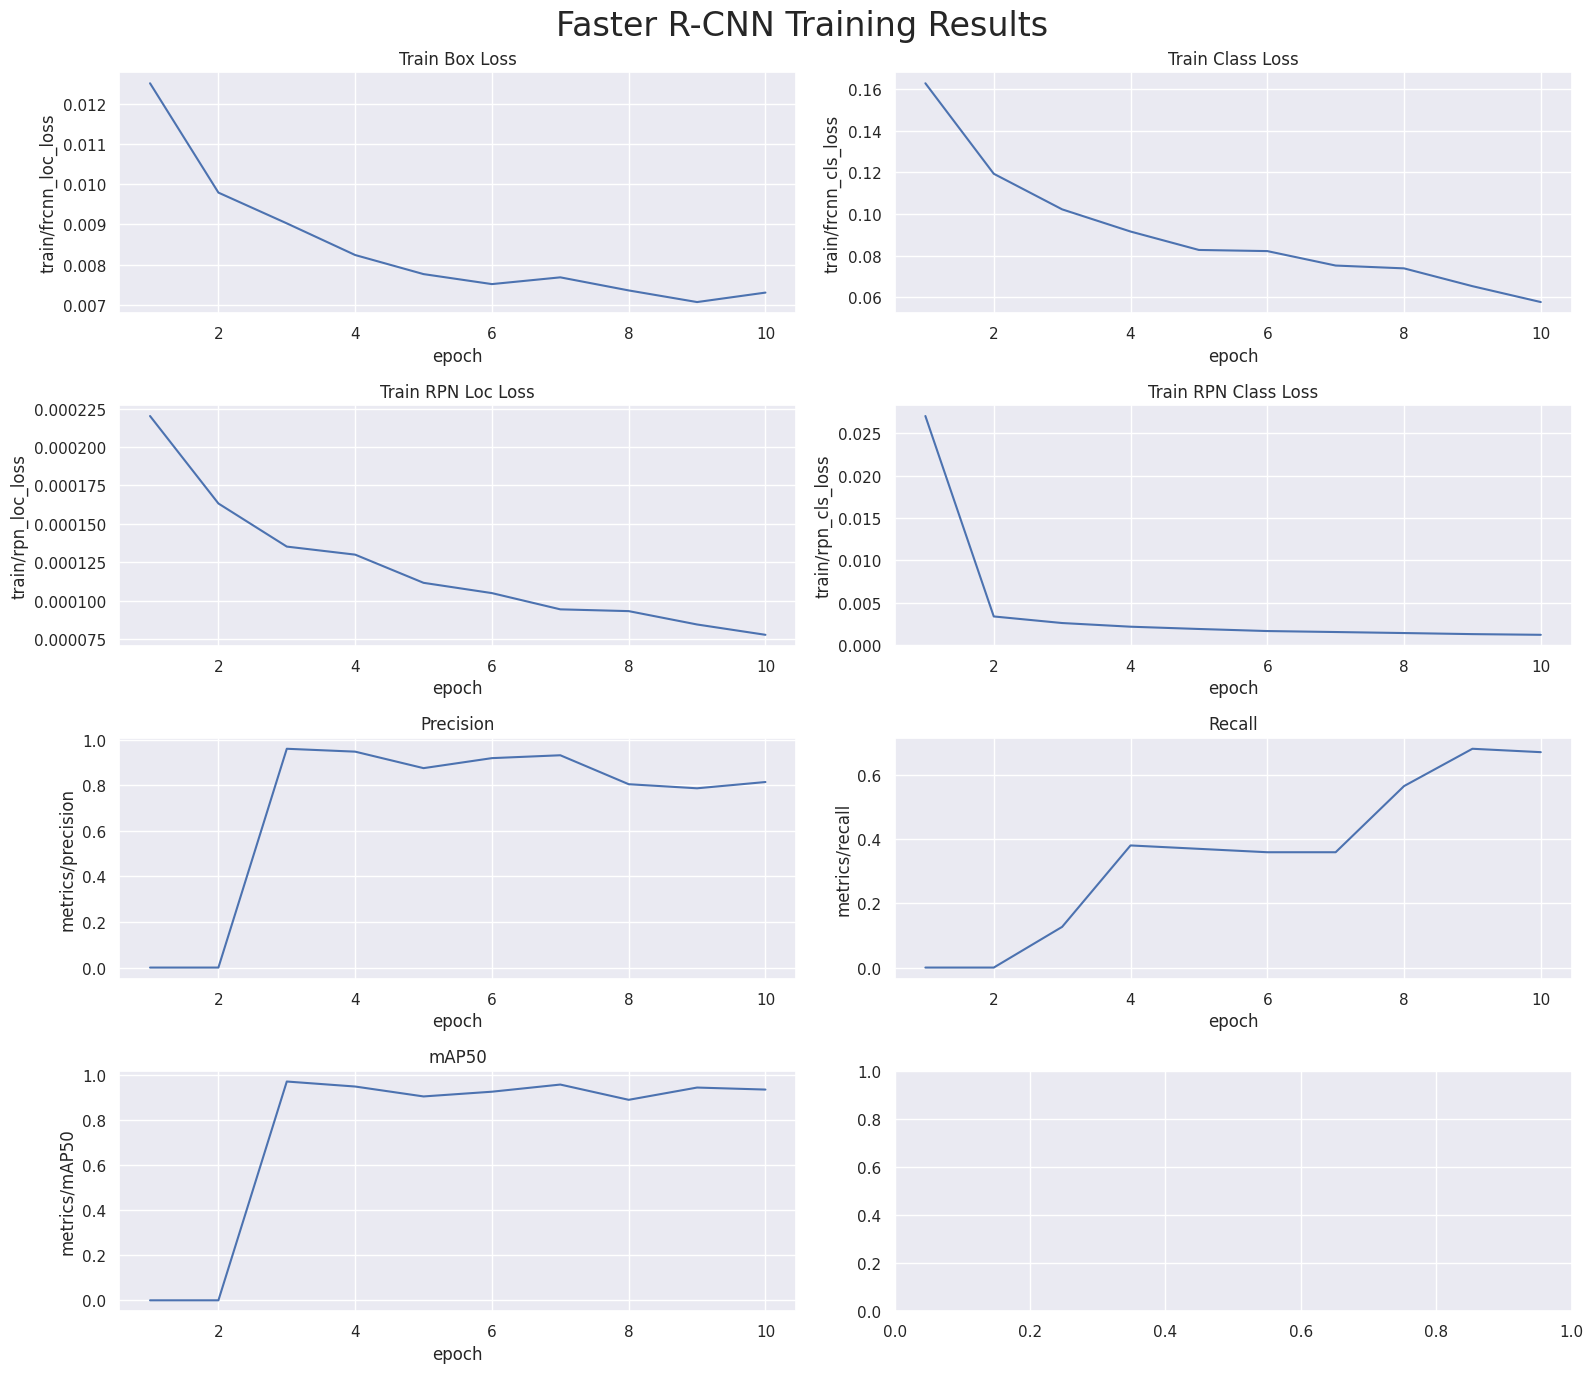

In [ ]:
results.columns = results.columns.str.strip()
sns.set(style='darkgrid')

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 14))

sns.lineplot(x='epoch', y='train/frcnn_loc_loss', data=results, ax=axs[0,0])
axs[0,0].set_title('Train Box Loss')

sns.lineplot(x='epoch', y='train/frcnn_cls_loss', data=results, ax=axs[0,1])
axs[0,1].set_title('Train Class Loss')

sns.lineplot(x='epoch', y='train/rpn_loc_loss', data=results, ax=axs[1,0])
axs[1,0].set_title('Train RPN Loc Loss')

sns.lineplot(x='epoch', y='train/rpn_cls_loss', data=results, ax=axs[1,1])
axs[1,1].set_title('Train RPN Class Loss')

sns.lineplot(x='epoch', y='metrics/precision', data=results, ax=axs[2,0])
axs[2,0].set_title('Precision')

sns.lineplot(x='epoch', y='metrics/recall', data=results, ax=axs[2,1])
axs[2,1].set_title('Recall')

sns.lineplot(x='epoch', y='metrics/mAP50', data=results, ax=axs[3,0])
axs[3,0].set_title('mAP50')

plt.suptitle('Faster R-CNN Training Results', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()


In [ ]:
test_TP, test_FP, test_FN, test_list_ious, test_all_preds = evaluate_model(model, test_loader, device, iou_thr=0.5)
test_scores, test_matches = zip(*test_all_preds)
test_precision, test_recall, _ = precision_recall_curve(test_matches, test_scores)
pr_df = pd.DataFrame({"recall": test_recall, "precision": test_precision})
ap = auc(test_recall, test_precision)

Evaluating:   0%|          | 0/223 [00:00<?, ?it/s]

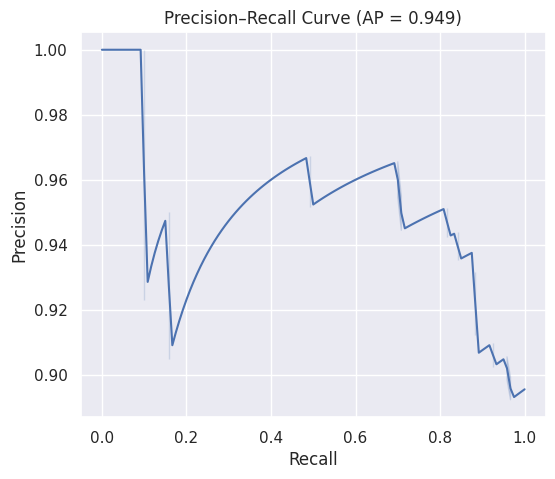

In [ ]:
plt.figure(figsize=(6, 5))
sns.lineplot(data=pr_df, x="recall", y="precision")
plt.title(f"Precision–Recall Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

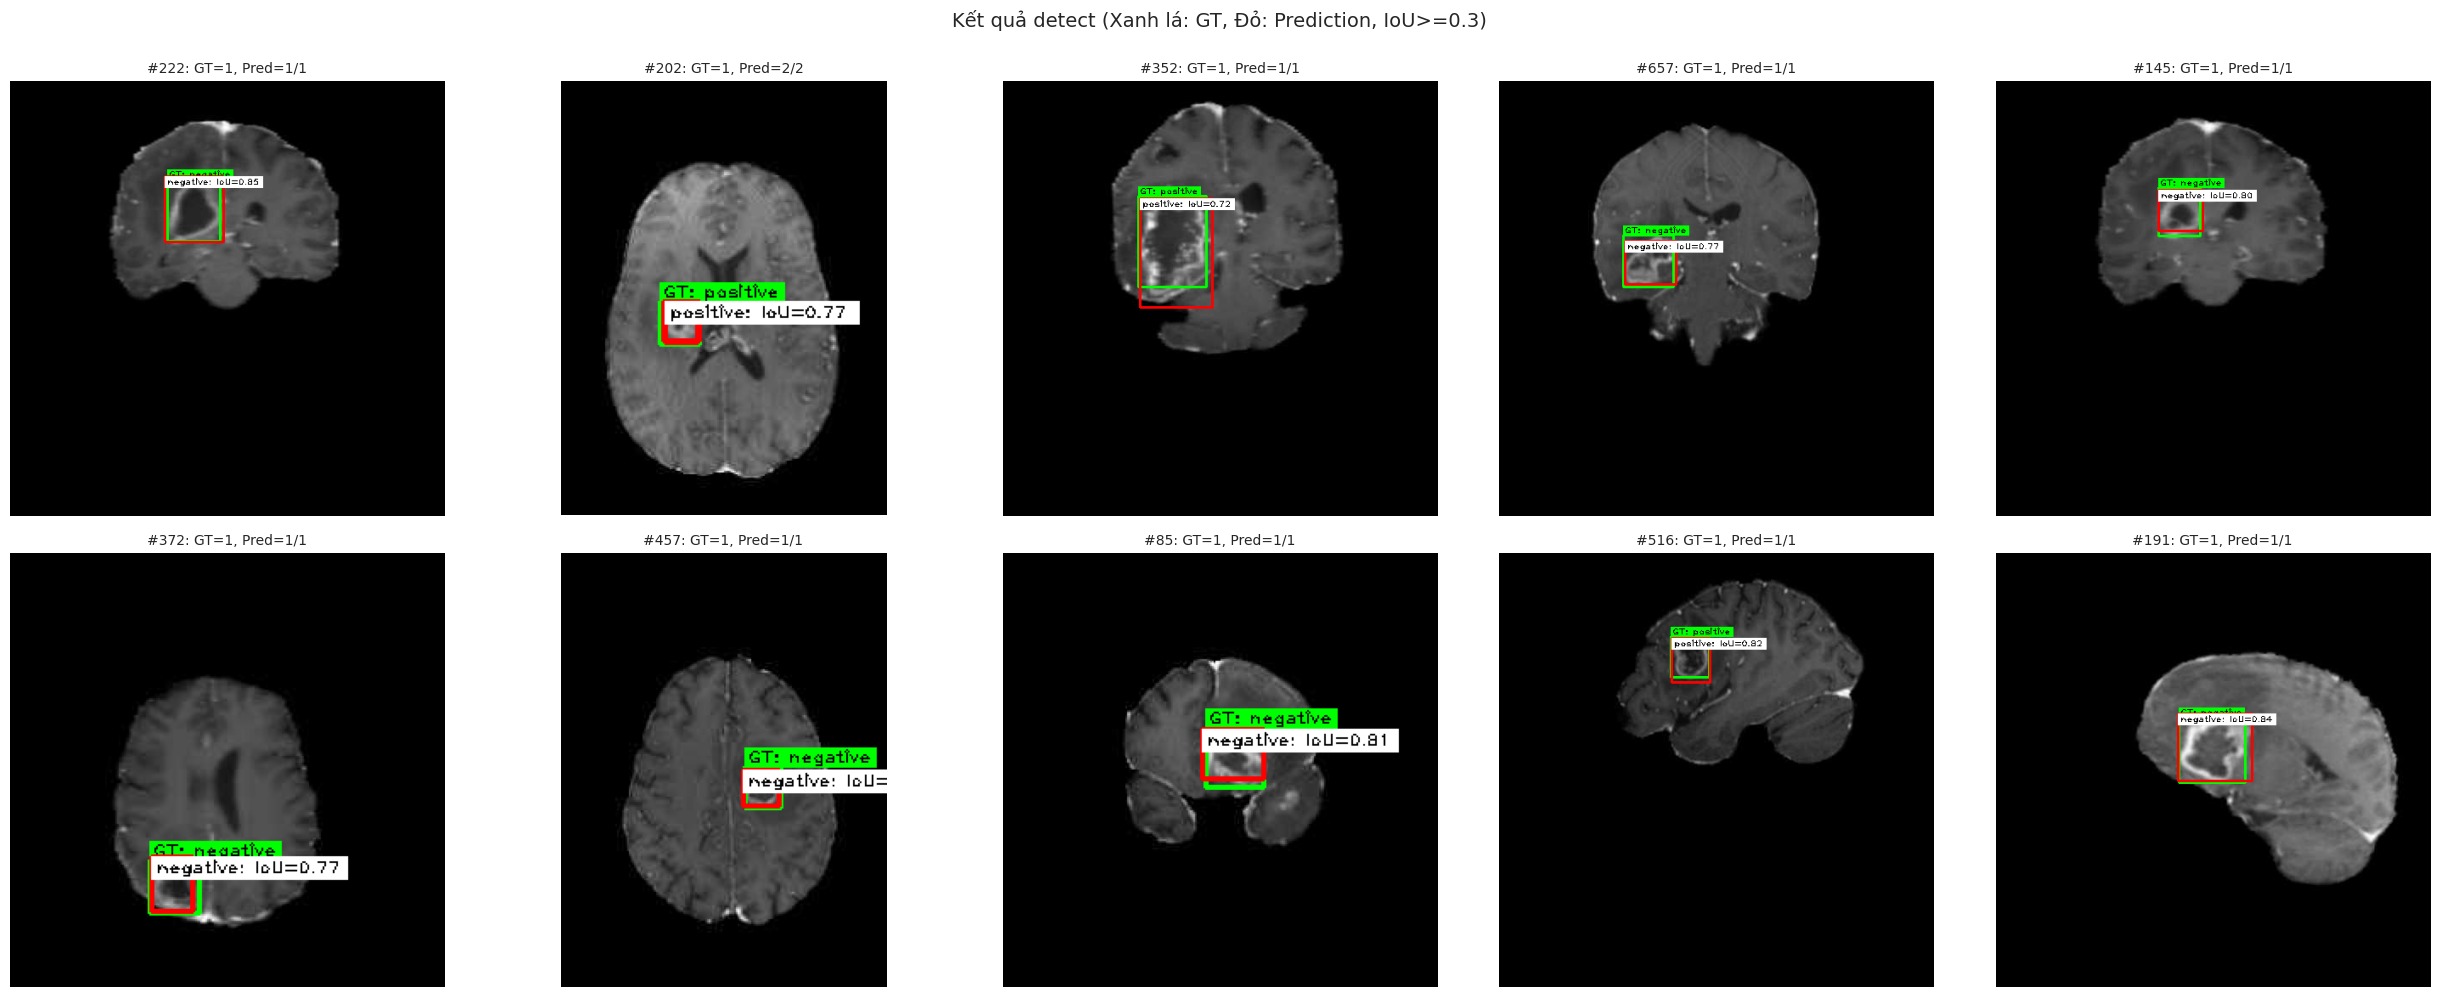

In [ ]:
model.eval()

def match_pred_to_gt(pred_boxes, gt_boxes, iou_threshold=0.5):
    """Match predicted boxes với GT boxes dựa trên IoU (sử dụng hàm get_iou có sẵn)"""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return np.zeros(len(pred_boxes)), np.zeros(len(pred_boxes))

    pred_boxes_tensor = torch.from_numpy(pred_boxes).float()
    gt_boxes_tensor = torch.from_numpy(gt_boxes).float()

    ious_tensor = get_iou(gt_boxes_tensor, pred_boxes_tensor)  # (N_gt, N_pred)
    ious = ious_tensor.cpu().numpy()

    max_ious = np.max(ious, axis=0)
    matched_gt_idx = np.argmax(ious, axis=0)

    return max_ious, matched_gt_idx

num_samples = min(10, len(train_dataset))
random_indices = random.sample(range(len(train_dataset)), num_samples)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

IOU_THRESHOLD = 0.3

for idx, ax in zip(random_indices, axes):
    img, target, fname = train_dataset[idx]
    im_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        rpn_out, frcnn_out = model(im_tensor, None)

    boxes = frcnn_out['boxes'].detach().cpu().numpy()
    labels = frcnn_out['labels'].detach().cpu().numpy()
    scores = frcnn_out['scores'].detach().cpu().numpy()

    im_bgr = cv2.imread(fname)
    vis = im_bgr.copy()

    gt_boxes = target['bboxes'].cpu().numpy()
    gt_labels = target['labels'].cpu().numpy()

    for box, label in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label_name = train_dataset.dataset.idx2label[int(label)]
        text = f"GT: {label_name}"
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_PLAIN, 0.7, 1)
        cv2.rectangle(vis, (x1, y1 - th - 4), (x1 + tw + 4, y1), (0, 255, 0), -1)
        cv2.putText(vis, text, (x1 + 2, y1 - 2), cv2.FONT_HERSHEY_PLAIN, 0.7, (0, 0, 0), 1)

    if len(boxes) > 0 and len(gt_boxes) > 0:
        ious, matched_gt_indices = match_pred_to_gt(boxes, gt_boxes)

        valid_mask = ious >= IOU_THRESHOLD
        boxes_filtered = boxes[valid_mask]
        labels_filtered = labels[valid_mask]
        scores_filtered = scores[valid_mask]
        ious_filtered = ious[valid_mask]

        for box, label, score, iou in zip(boxes_filtered, labels_filtered, scores_filtered, ious_filtered):
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
            label_name = train_dataset.dataset.idx2label[int(label)]
            text = f"{label_name}: IoU={iou:.2f}"
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_PLAIN, 0.7, 1)
            cv2.rectangle(vis, (x1, y1), (x1 + tw + 6, y1 + th + 6), (255, 255, 255), -1)
            cv2.putText(vis, text, (x1 + 3, y1 + th + 3), cv2.FONT_HERSHEY_PLAIN, 0.7, (0, 0, 0), 1)

        num_pred_filtered = len(boxes_filtered)
    else:
        num_pred_filtered = 0

    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    ax.imshow(vis_rgb)
    ax.axis('off')
    ax.set_title(f"#{idx}: GT={len(gt_boxes)}, Pred={num_pred_filtered}/{len(boxes)}", fontsize=10)

plt.suptitle(f'Kết quả detect (Xanh lá: GT, Đỏ: Prediction, IoU>={IOU_THRESHOLD})', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
torch.save(model, '/content/drive/MyDrive/models/Final_Model.pth')

Mounted at /content/drive
